In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
 
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.to_csv('diabetes_data.csv', index=False)

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

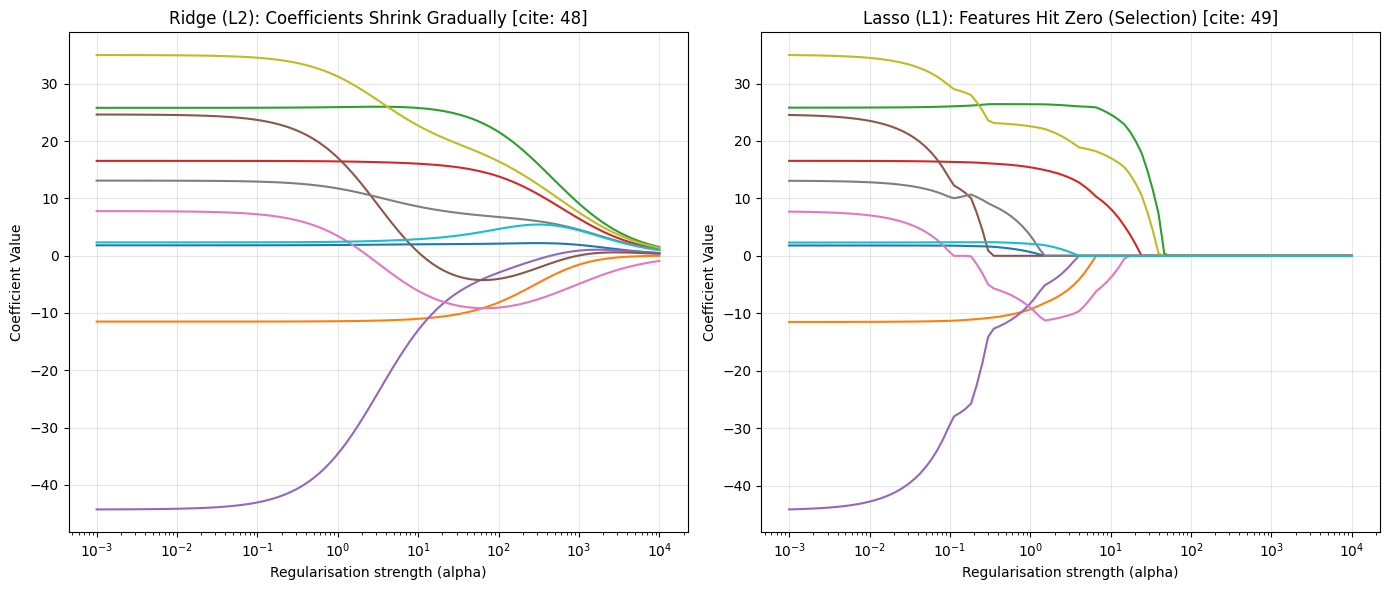

In [3]:
alphas = np.logspace(-3, 4, 100)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.title('Ridge (L2): Coefficients Shrink Gradually [cite: 48]')
plt.xlabel('Regularisation strength (alpha)')
plt.ylabel('Coefficient Value')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.title('Lasso (L1): Features Hit Zero (Selection) [cite: 49]')
plt.xlabel('Regularisation strength (alpha)')
plt.ylabel('Coefficient Value')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

print(f"Best Ridge Alpha: {ridge_cv.alpha_:.4f}")
print(f"Best Lasso Alpha: {lasso_cv.alpha_:.4f}")

lasso_features = pd.Series(lasso_cv.coef_, index=feature_names)
removed_features = lasso_features[lasso_features == 0].index.tolist()
print(f"Features removed by Lasso: {removed_features}")

Best Ridge Alpha: 39.4421
Best Lasso Alpha: 1.5199
Features removed by Lasso: ['age', 's2', 's4']


In [5]:
# Predict and evaluate
y_pred_ridge = ridge_cv.predict(X_test)
y_pred_lasso = lasso_cv.predict(X_test)

print(f"Ridge Test MSE: {mean_squared_error(y_test, y_pred_ridge):.2f}")
print(f"Lasso Test MSE: {mean_squared_error(y_test, y_pred_lasso):.2f}")

Ridge Test MSE: 2857.96
Lasso Test MSE: 2801.25
